# This notebook demonstrates a simple linear regression analysis using [R] to model Salary based on Years of Experience.

## Imports external packages and libraries

Install required external packages using `install.packages("pkgname")` and load with `library():`

`library(ggplot2)  # enables advanced plotting`

In [1]:
install.packages("ggplot2")
library(ggplot2)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



## Read dataset file and define x,y variables

Tell script to read data from "regression_data.csv"

Reminder, data file is one folder back.

Use ../ for code to work. 

`data <- read.csv("../regression_data.csv")`

Then, define x and y data

`x <- data$YearsExperience
y <- data$Salary`


In [2]:
data <- read.csv("../regression_data.csv")

x <- data$YearsExperience
y <- data$Salary

## Calculate regression line and print statistics

To calculate regression model, use: `model <- lm(y ~ x)` 

Analyze and print statistics for linear regression analysis:

- slope
- y-axis intercept
- r-squared value
- mean squared error
- linear function


In [3]:
model <- lm(y ~ x)

slope <- coef(model)[2]
intercept <- coef(model)[1]
r_squared <- summary(model)$r.squared
pred <- predict(model)
mse <- mean(pred - y)^2

cat("slope =", slope, "\n")
cat("y-intercept =", intercept, "\n") 
cat("R-squared value =", r_squared, "\n")
cat("mean standard error =", mse, "\n")
cat("y =", round(slope, 2), "* x +", round(intercept, 2), "\n")     #round(___, 2) rounds to two decimal places

slope = 8285.292 
y-intercept = 29203.52 
R-squared value = 0.7851516 
mean standard error = 4.468636e-23 
y = 8285.29 * x + 29203.52 


## Define data frame and create scatter plot with overlay regression line

**Make scatter plot** using `geom_point()` and data points red: `color = "red"`

**Overlay regression line** with `geom_smooth()` and make it blue: `color = "blue"`

**Add annotations** on graph using `annotate()`
- include linear function, r-square value rounded to 2 decimal points
- include MSE format in scientific notation, 3 significant figures

  
**Label plot title and x- and y-axis:**
title, xlabel, ylabel

`geom_smooth()` using formula = 'y ~ x'


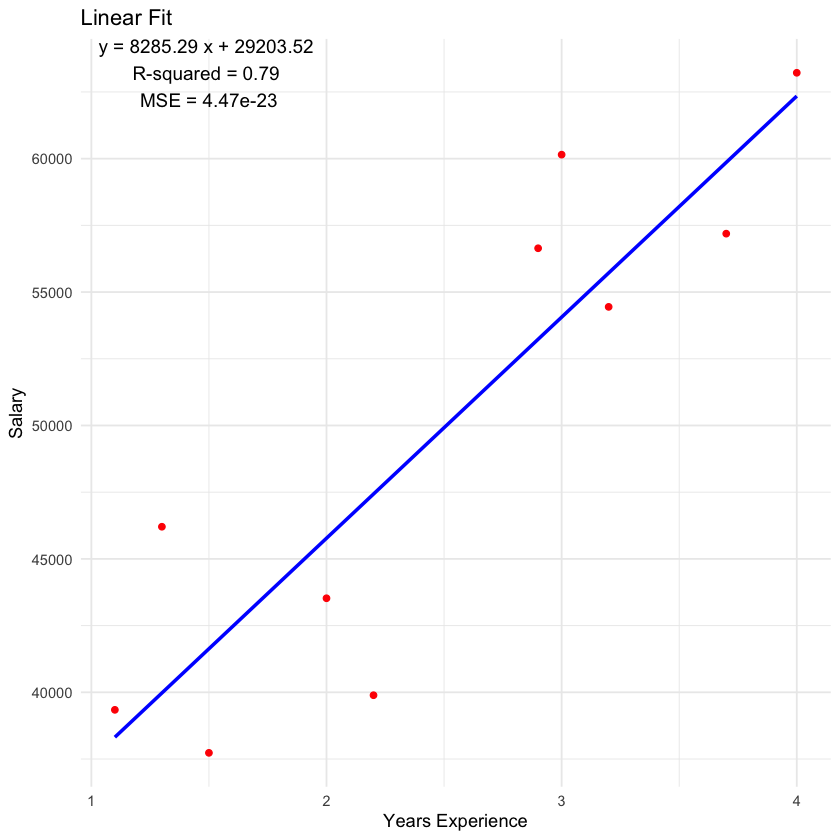

In [4]:
df <- data.frame(
  x = x,
  y = y
)

ggplot(df, aes(x = x, y = y)) +
  geom_point(color = "red") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  annotate(
      "text",
      x = 1.5, 
      y = max(df$y) - 0.5,
      label = paste(
          "y =", round(slope, 2), "x +", round(intercept, 2),
          "\nR-squared =", round(r_squared, 2),
          "\nMSE =", format(mse, scientific = TRUE, digits = 3)
      ),

      size = 4
  ) + 

labs(
    title = "Linear Fit", 
    x = "Years Experience", 
    y = "Salary"
) + 

theme_minimal()

## Show analysis summary and save generated plot as new file

Save figure into folder and label file as "lregression_plot_r.png"


In [5]:
summary(model)
print(plot)

ggsave("regression_plot_r.png")


Call:
lm(formula = y ~ x)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)    29204       4092   7.136 9.84e-05 ***
x               8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407


function (x, y, ...) 
UseMethod("plot")
<bytecode: 0x12da611b8>
<environment: namespace:base>


Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'


## Check command script is typed correctly in Terminal 

**Aka “If the user did not give exactly 3 arguments after the script name, show them the correct usage and quit.”**

Example: `cd linear-regression/manual` then type in command line `Rscript linear_model_r.R ../regression_data.csv YearsExperience Salary`

`args` list of words from Terminal command, [1] [2] and [3]

`!= 3` script expects exactly 3 arguments

**Print a reminder on Terminal** of how to correctly run r script:

`("Usage: python linear_regression_python.py <filename> <x_column> <y_column>")` 

`sys.exit(1)` Stops the program right away, (1) means "this ended because of an error and was not a successful run"

 **Define the arguments:** script expects exactly 3 arguments

Code:
```
args <- commandArgs(trailingOnly = TRUE)
if (length(args) != 3) {
  stop("Usage: Rscript linear_model_r.R <filename> <x_column> <y_column>")
}

filename <- args[1]
x_col <- args[2]
y_col <- args[3]
```